In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import blimpy as bl
import glob
import os
%matplotlib inline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [ ]:
csvs = np.sort(glob.glob('/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/*trimmed.csv'))
print(len(csvs), 'csvs')

window = 0.003 # 3 kHz window
foff = 2.7939677238464355e-06
tsamp = 18.253611008
w = window//foff # in bin units

for iii, csv in enumerate(csvs):
    if iii < 2941:
        continue
    print(csv)
    df = pd.read_csv(csv)
    if len(df) < 100:
        continue
    print(iii,'out of',len(csvs))
    signal_frequencies = df['Freq'].values
    signal_drifts = df['DriftRate'].values
    print(signal_frequencies.min())
    print(signal_frequencies.max())
    freq_range = signal_frequencies.max() - signal_frequencies.min()

    basename = os.path.basename(csv)
    idx = basename.split('_')[0]
    h5_lst = glob.glob(f'/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/{idx}_*_h5_files.lst')[0]
    print(glob.glob(f'/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/{idx}_*_h5_files.lst'))
    with open(h5_lst) as file:
        h5s = [line.rstrip() for line in file]
    for h5 in h5s:
        print(h5)

    # dice
    f_start_list = np.arange(start=signal_frequencies.min()-1, stop=signal_frequencies.max()+1, step=187.5)
    print(len(f_start_list),'h5s needed')
    for f_start in f_start_list:
        f_stop = np.min([f_start+187.5, signal_frequencies.max()])
        for ii, h5 in enumerate(h5s):
            print(f'Dicing .h5 #{ii}')
            outfile = '/datax/scratch/benjb/bl_nearby_stars/temp_diced_h5s/' + os.path.basename(h5)[:-2] + f'{f_start}_{f_stop}.h5'
            console = f'bldice -f {h5} -b {f_start} -e {f_stop} -x .h5 -o {outfile} -l 20'
            os.system(console)

    # make PDFs
    for f_start in f_start_list:
        f_stop = np.min([f_start+187.5, signal_frequencies.max()])
        sigfreqs_for_this_batch = signal_frequencies[(signal_frequencies > f_start)&(signal_frequencies < f_stop)]
        sigdrifts_for_this_batch = signal_drifts[(signal_frequencies > f_start)&(signal_frequencies < f_stop)]
        num_pdfs = len(sigfreqs_for_this_batch)//100
        if len(sigfreqs_for_this_batch)%100 > 0:
            num_pdfs += 1 # add a pdf if there's a remainder in the number of signals
        for p in range(num_pdfs):
            fig = plt.figure(figsize=(30,30))
            outer_grid = fig.add_gridspec(10, 10, wspace=0.05, hspace=0.1)
            pfname = f'/datax/scratch/benjb/bl_nearby_stars/seticore_output/plotevent_proxy/{os.path.basename(csv)[:-21]}_{f_start}_{f_stop}_{p}.pdf'
            if os.path.exists(pfname):
                print(f'Already plotted ({pfname})! Continuing ...')
                continue
            for k in range(6):
                this_h5 = '/datax/scratch/benjb/bl_nearby_stars/temp_diced_h5s/' + os.path.basename(h5s[k])[:-2] + f'{f_start}_{f_stop}.h5'
                print(this_h5)
                fb = bl.Waterfall(this_h5, load_data=True)
                print(fb.header)
                freqs, data = fb.grab_data()
                for a in range(10):
                    for b in range(10):
                        signal_idx = 100*p + 10*a + b
                        # gridspec inside gridspec
                        inner_grid = outer_grid[a, b].subgridspec(6, 1, wspace=0, hspace=0)
                        ax = fig.add_subplot(inner_grid[k])
                        ax.set_yticks([])
                        ax.set_xticks([])
                        if signal_idx < len(sigfreqs_for_this_batch):
                            # plot
                            print('Plotting signal', signal_idx)
                            f = sigfreqs_for_this_batch[signal_idx]
                            d = -sigdrifts_for_this_batch[signal_idx] # negative sign accounts for sign of foff
                            fi = np.argmin(np.abs(freqs-f)) # center frequency index
                            data_window = data[:,int(fi-w//2):int(fi+w//2)]
                            ax.imshow(data_window, aspect='auto', interpolation='none')
                            offset = 50
                            ax.plot([w/2-offset + k*d*(1e-6)/foff*tsamp*16, w/2+(k+1)*d*(1e-6)/foff*tsamp*16-offset], [0,15], color='r', ls='--')
                        if k == 0:
                            ax.set_title(f'{f} MHz, {np.round(-d,4)} Hz/s', size=8)
            plt.savefig(f'/datax/scratch/benjb/bl_nearby_stars/seticore_output/plotevent_proxy/{os.path.basename(csv)[:-21]}_{f_start}_{f_stop}_{p}.pdf', bbox_inches='tight')
            plt.show()


3310 csvs
/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/6926_31458_HIP117463_Rcvr4_6_blc54_f3_trimmed.csv
2941 out of 3310
4128.748718
4239.639339
['/datax/scratch/benjb/bl_nearby_stars/seticore_output/findevent/6926_31458_HIP117463_Rcvr4_6_blc54_h5_files.lst']
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_31692_HIP117463_0027.gpuspec.0000.h5
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_32030_HIP116877_0028.gpuspec.0000.h5
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_32368_HIP117463_0029.gpuspec.0000.h5
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_32699_HIP117169_0030.gpuspec.0000.h5
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_33030_HIP117463_0031.gpuspec.0000.h5
/datag/pipeline/AGBT18B_999_19/blc54_blp04/blc54_guppi_58369_33363_HIP117179_0032.gpuspec.0000.h5
1 h5s needed
Dicing .h5 #0
Dicing .h5 #1


In [ ]:
#fb = bl.Waterfall('/datag/pipeline/AGBT17B_999_21/collate2/spliced_blc00010203040506o7o0111213141516o0212223242526o7o031323334353637_guppi_58000_09701_GJ702B_0057.gpuspec.0000.h5', load_data=False)

In [ ]:
#filename = '/datag/pipeline/AGBT17B_999_21/collate2/spliced_blc00010203040506o7o0111213141516o0212223242526o7o031323334353637_guppi_58000_09701_GJ702B_0057.gpuspec.0000.h5'
#fb_narrow = bl.Waterfall(filename, f_start=4192, f_stop=4203)

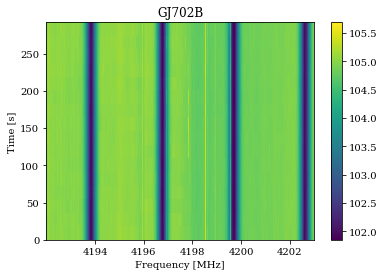

In [ ]:
#fb_narrow.plot_waterfall()

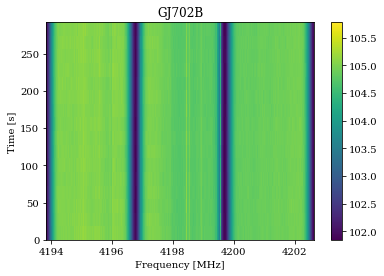

In [ ]:
#filename = '/datax/scratch/benjb/bl_nearby_stars/temp_diced_h5s/spliced_blc00010203040506o7o0111213141516o0212223242526o7o031323334353637_guppi_58000_09701_GJ702B_0057.gpuspec.0000.4194.530241_4202.576354.h5'
#fb1 = bl.Waterfall(filename)
#fb1.plot_waterfall()